<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names   = iris.target_names

print("=" * 50)
print("IRIS DATASET INFO")
print("=" * 50)
print(f"Total Samples   : {X.shape[0]}")
print(f"Total Features  : {X.shape[1]}")
print(f"Feature Names   : {feature_names}")
print(f"Classes         : {class_names}")
print(f"Samples/Class   : {np.bincount(y)}")

IRIS DATASET INFO
Total Samples   : 150
Total Features  : 4
Feature Names   : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes         : ['setosa' 'versicolor' 'virginica']
Samples/Class   : [50 50 50]


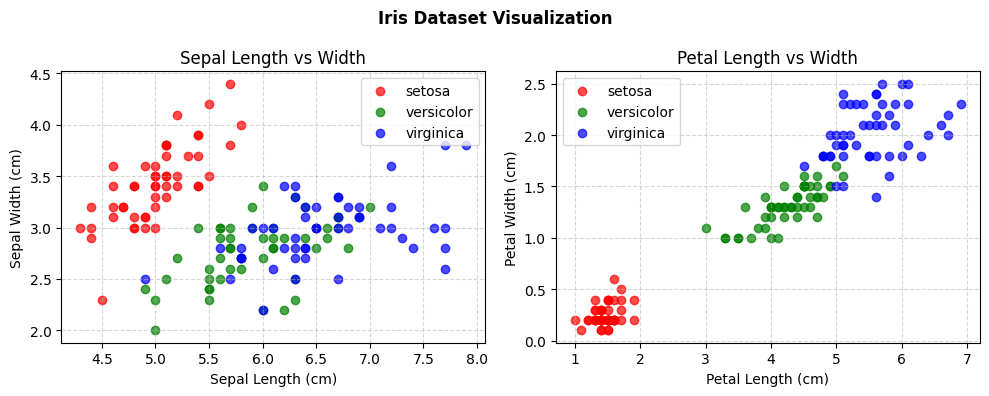

In [3]:
plt.figure(figsize=(10, 4))

# Plot 1: Sepal
plt.subplot(1, 2, 1)
colors = ['red', 'green', 'blue']
for i, cls in enumerate(class_names):
    plt.scatter(X[y == i, 0], X[y == i, 1],
                label=cls, color=colors[i], alpha=0.7)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Width')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Petal
plt.subplot(1, 2, 2)
for i, cls in enumerate(class_names):
    plt.scatter(X[y == i, 2], X[y == i, 3],
                label=cls, color=colors[i], alpha=0.7)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Width')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Iris Dataset Visualization', fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain samples : {X_train.shape[0]}")
print(f"Test samples  : {X_test.shape[0]}")


Train samples : 120
Test samples  : 30


In [5]:
dt_model = DecisionTreeClassifier(
    max_depth=4,          # Limit depth for readability
    random_state=42,
    criterion='gini'      # Gini impurity for splitting
)

dt_model.fit(X_train, y_train)

print("\nDecision Tree Trained Successfully!")
print(f"Tree Depth     : {dt_model.get_depth()}")
print(f"Tree Leaves    : {dt_model.get_n_leaves()}")


Decision Tree Trained Successfully!
Tree Depth     : 4
Tree Leaves    : 7


In [6]:
y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy  : {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=class_names))


Test Accuracy  : 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



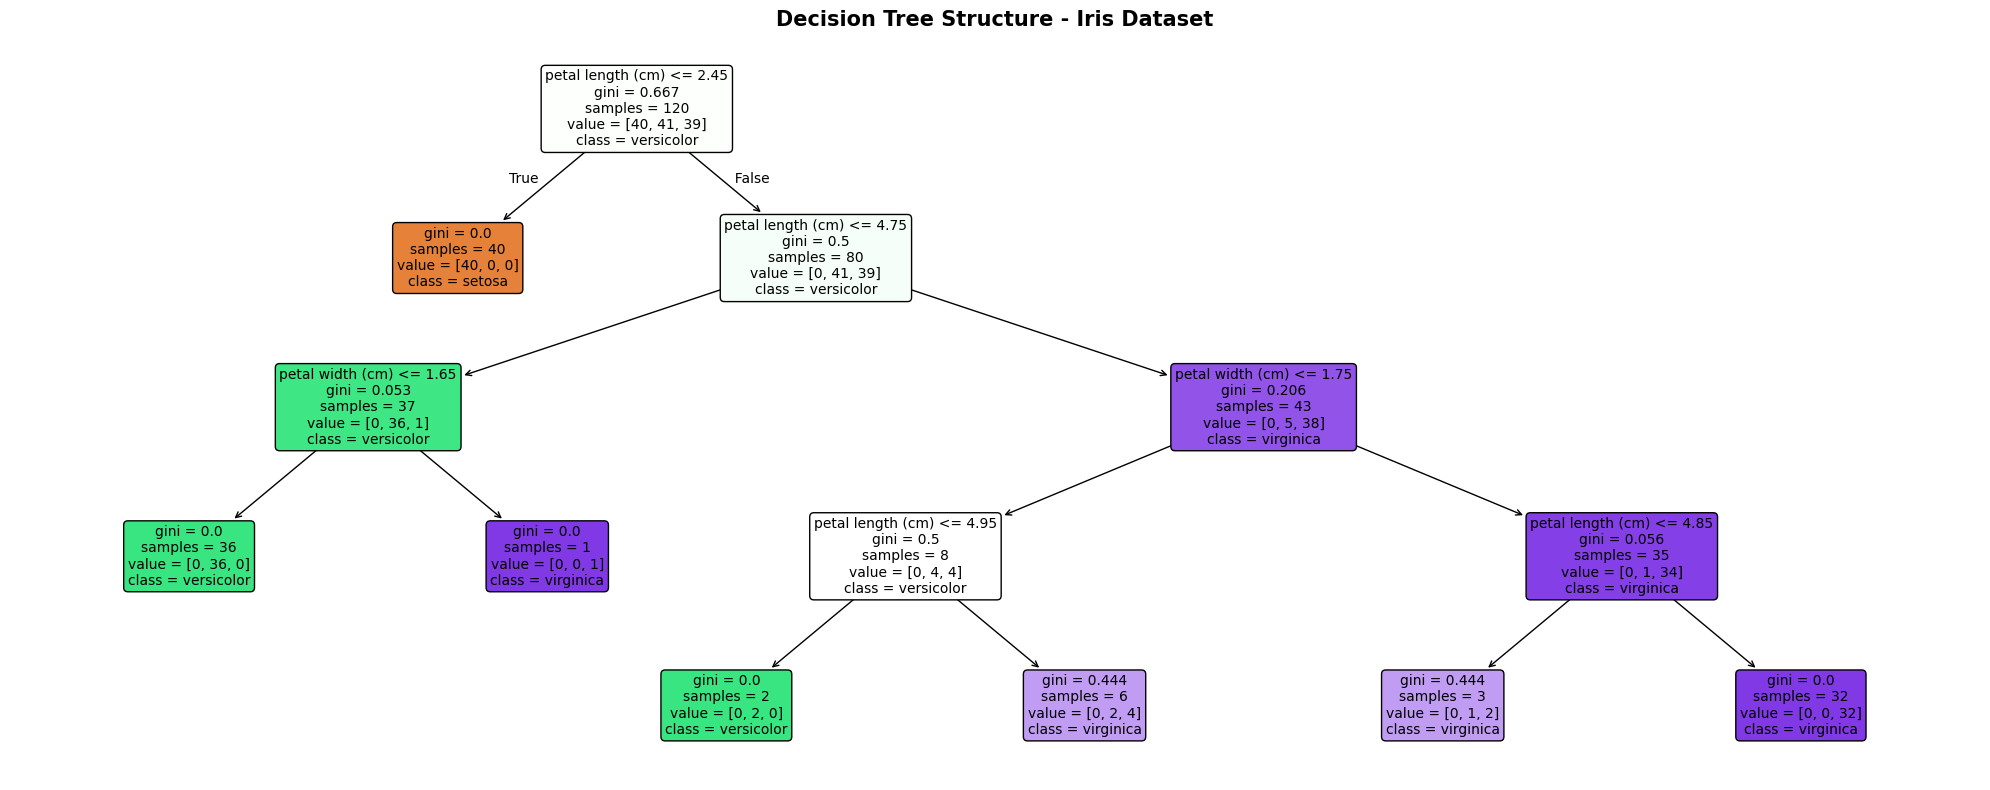

In [7]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,           # Color nodes by class
    rounded=True,          # Rounded boxes
    fontsize=10
)
plt.title('Decision Tree Structure - Iris Dataset',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
importances = dt_model.feature_importances_

# Sort by importance
indices   = np.argsort(importances)[::-1]
sorted_features    = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

print("\nFeature Importances:")
print("-" * 35)
for f, imp in zip(sorted_features, sorted_importances):
    print(f"  {f:<30} : {imp:.4f}")


Feature Importances:
-----------------------------------
  petal length (cm)              : 0.9363
  petal width (cm)               : 0.0637
  sepal width (cm)               : 0.0000
  sepal length (cm)              : 0.0000


In [10]:
from sklearn.tree import export_text

rules = export_text(dt_model, feature_names=list(feature_names))
print("\nDecision Rules:")
print("=" * 50)
print(rules)


Decision Rules:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: 2
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2

